Load in and Prepare Data

In [1]:
import os
import pandas as pd
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchmetrics.regression import MeanSquaredError
device = torch.device("cpu") 

#Load Data
#Exclude Columns Related to Data on the Specific Director.
#Want this to be a tool for new directors/producers trying to break in
# So I don't want the model tied to director details
# Also drop the unused genres list column
cols_to_exclude = ["genres","director_name","director_professions","director_birthYear","director_deathYear", "Production budget $"]

target_cols = ["movie_title","Production budget $"]


x = pd.read_csv("movie_statistic_dataset_processed_buckets.csv",usecols=lambda column: column not in cols_to_exclude)
y = pd.read_csv("movie_statistic_dataset_processed_buckets.csv",usecols=target_cols)
# Convert Year String to Int
x['production_date'] = pd.to_datetime(x['production_date']).dt.year.astype(int)

#Set the title as the index
x = x.set_index('movie_title')
y = y.set_index('movie_title')

from sklearn.model_selection import train_test_split
#Split the data
rand_seed=1
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=rand_seed) 

# Scale Data (so consistent with other models)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

#Batch Size
batch_size = 64

#Prepare Training Data
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True)

print(f'X Tensor Size: {X_train_tensor.size()}')

#Prepare Testing Data
# Testing Data
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32 )
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X Tensor Size: torch.Size([3504, 20])


Design Neural Nets (Pyramid)

In [2]:
input_size = 20
output_size = 1

In [3]:
class Pyramid2x(nn.Module):
    def __init__(self):
        super(Pyramid2x, self).__init__()
        
        self.linear_LeakyReLU_stack = nn.Sequential(
            nn.Linear(input_size, 2*input_size),
            nn.LeakyReLU(),
            nn.Linear(2*input_size, input_size),
            nn.LeakyReLU(),
            nn.Linear(input_size, input_size//2),
            nn.LeakyReLU(),
            nn.Linear(input_size//2, output_size)
            
        )
    def forward(self, x):

        logits = self.linear_LeakyReLU_stack(x)
        return logits

class Pyramid4x(nn.Module):
    def __init__(self):
        super(Pyramid4x, self).__init__()
        
        self.linear_LeakyReLU_stack = nn.Sequential(
            nn.Linear(input_size, 4*input_size),
            nn.LeakyReLU(),
            nn.Linear(4*input_size, 2*input_size),
            nn.LeakyReLU(),
            nn.Linear(2*input_size, input_size),
            nn.LeakyReLU(),
            nn.Linear(input_size, input_size//2),
            nn.LeakyReLU(),
            nn.Linear(input_size//2, output_size)
            
        )
    def forward(self, x):

        logits = self.linear_LeakyReLU_stack(x)
        return logits




Define Training and Testing Loops

In [4]:
from torchmetrics import MeanSquaredError, R2Score
from torchmetrics.functional.regression import r2_score
import matplotlib.pyplot as plt

# Training Loop
def trainloop(num_epochs, model, train_loader,optimizer, criterion):
    for epoch in range(num_epochs): 
        model.train() 
        for X,y in train_loader:
            optimizer.zero_grad() 
            y_pred = model(X) 
            loss = criterion(y_pred,y) 
            loss.backward() 
            optimizer.step() 
    

# Testing Loop
def testloop(model, test_loader,criterion,mse,r2):
    model.eval() # Not in training mode
    mse_metric = MeanSquaredError()
    r2_metric = R2Score() 
    with torch.no_grad():
        for X,y in test_loader:
            y_pred = model(X)
            mse_metric.update(y_pred,y)
            r2_metric.update(y_pred,y)
    mse.append(mse_metric.compute()) 
    r2.append(r2_metric.compute())
    
# Run Model            
def runNet(num_epochs, model ,trainload, testload, optimizer,criterion,variation,mse,r2): 
    
    print(f'Model: {model}')
    for t in range(num_epochs):
        print(f"Epoch {t+1}\n----------")
        trainloop(num_epochs, model, trainload, optimizer, criterion)
        testloop(model, testload,criterion,mse,r2)
        
        
    print("Done")
    print(f'Test MSE in Final Epoch: {mse[-1]}')
    print(f'Test R2 in Final Epoch: {r2[-1]}')
    #Plotting

    plt.scatter(range(1,num_epochs+1),mse)
    plt.title(f'{variation} Testing MSE by Epoch')
    plt.savefig(f"Plots/Leaky ReLU {variation} MSE")
    plt.show()    
    plt.scatter(range(1,num_epochs+1),r2)
    plt.title(f'{variation} Testing R^2 by Epoch')
    plt.savefig(f"Plots/Leaky ReLU {variation} R2")
    plt.show()

        

Testing Models

Model: Pyramid2x(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=40, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=40, out_features=20, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=20, out_features=10, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=10, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epoch 

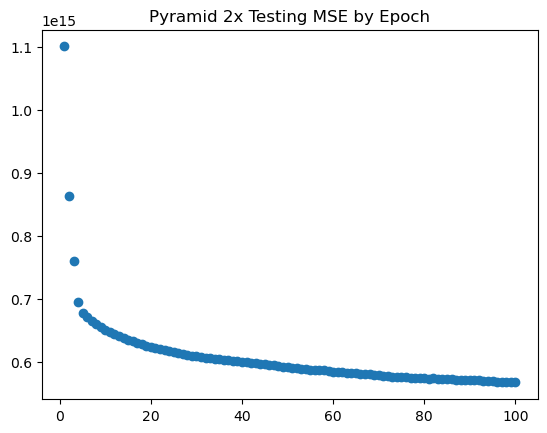

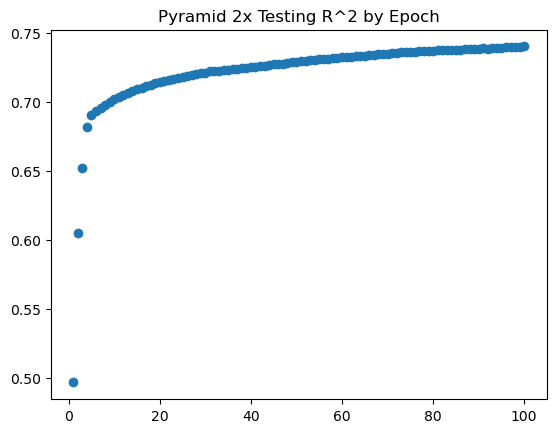

Model: Pyramid4x(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=10, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Linear(in_features=10, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 

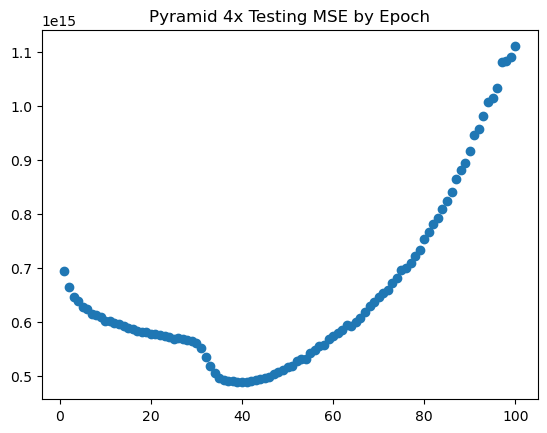

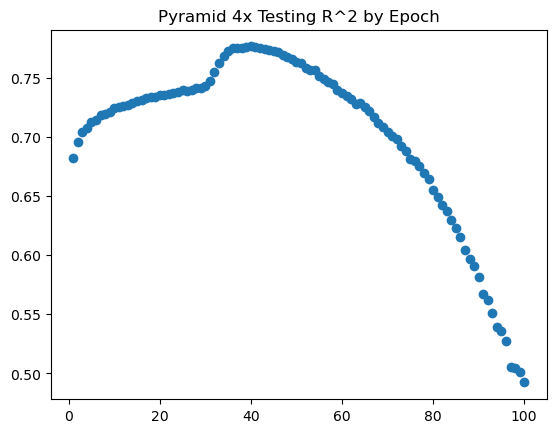

In [5]:
import random
import numpy as np
SEED = 1 
random.seed(SEED) 
np.random.seed(SEED) 
torch.manual_seed(SEED) 
if torch.cuda.is_available(): 
    torch.cuda.manual_seed_all(SEED)

epoch_count=100
lr = 0.001
pyramid2 = Pyramid2x()
pyramid4 = Pyramid4x()

mse_p2 = []
r_p2 = []
runNet(epoch_count, pyramid2 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid2.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 2x",mse=mse_p2,r2=r_p2)

mse_p4 = []
r_p4 = []
runNet(epoch_count, pyramid4 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid4.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4x",mse=mse_p4,r2=r_p4)


Model: Pyramid4x(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=10, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Linear(in_features=10, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 

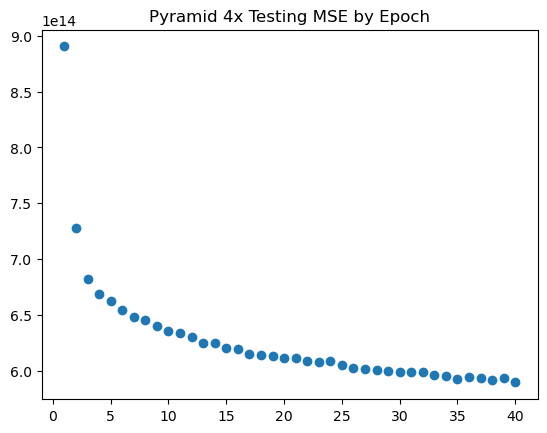

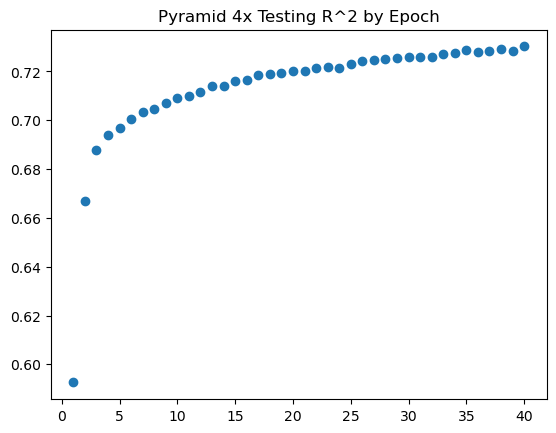

In [6]:
mse_p41 = []
r_p41 = []
pyramid41 = Pyramid4x()
runNet(40, pyramid41 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid41.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4x",mse=mse_p41,r2=r_p41)

Model: Pyramid2x(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=40, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=40, out_features=20, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=20, out_features=10, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=10, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epoch 

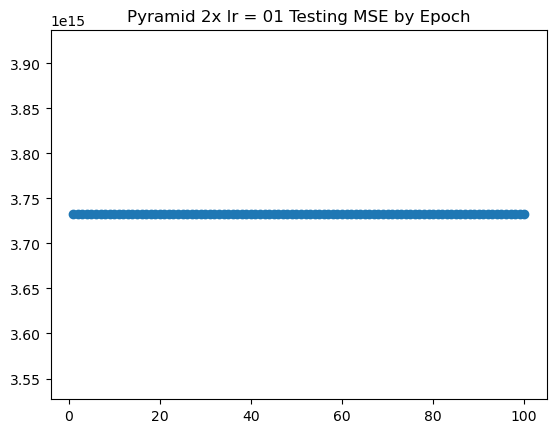

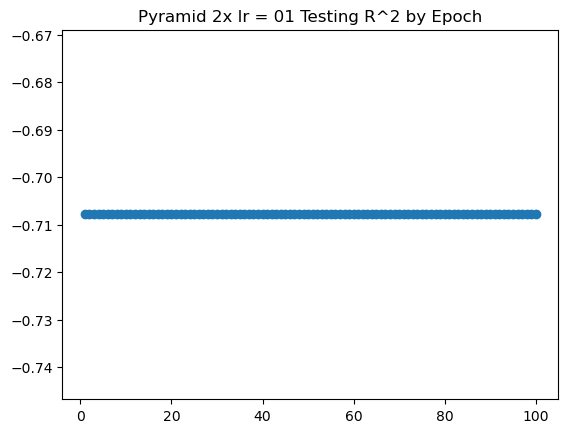

In [8]:
mse_p2_1 = []
r_p2_1 = []
pyramid2_1 = Pyramid2x()
runNet(epoch_count, pyramid2_1 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid2.parameters(),lr=.01),criterion=nn.MSELoss(),variation="Pyramid 2x lr = 01",mse=mse_p2_1,r2=r_p2_1)

In [9]:
#Add Batchnorm
class Pyramid2xBN(nn.Module):
    def __init__(self):
        super(Pyramid2xBN, self).__init__()
        
        self.linear_LeakyReLU_stack = nn.Sequential(
            nn.Linear(input_size, 2*input_size),
            nn.BatchNorm1d(2*input_size),
            nn.LeakyReLU(),
            nn.Linear(2*input_size, input_size),
            nn.BatchNorm1d(input_size),
            nn.LeakyReLU(),
            nn.Linear(input_size, input_size//2),
            nn.BatchNorm1d(input_size//2),
            nn.LeakyReLU(),
            nn.Linear(input_size//2, output_size)
            
        )
    def forward(self, x):

        logits = self.linear_LeakyReLU_stack(x)
        return logits

Model: Pyramid2xBN(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=40, bias=True)
    (1): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=40, out_features=20, bias=True)
    (4): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=10, bias=True)
    (7): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Linear(in_features=10, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
--------

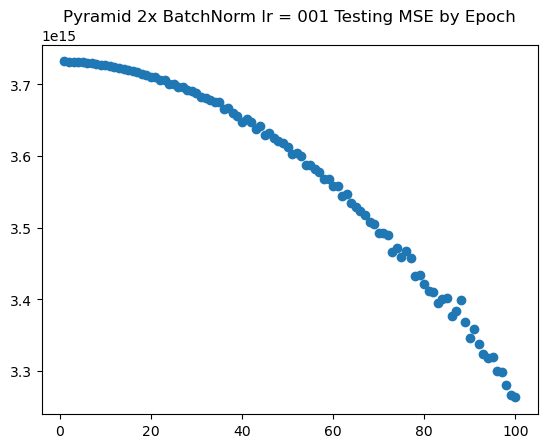

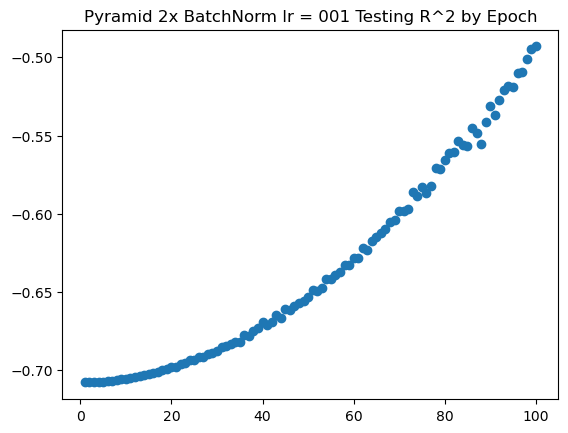

In [10]:
mse_p2_bn = []
r_p2_bn = []
pyramid2_bn = Pyramid2xBN()
runNet(epoch_count, pyramid2_bn ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid2_bn.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 2x BatchNorm lr = 001",mse=mse_p2_bn,r2=r_p2_bn)

Model: Pyramid2xBN(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=40, bias=True)
    (1): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=40, out_features=20, bias=True)
    (4): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=10, bias=True)
    (7): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Linear(in_features=10, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
--------

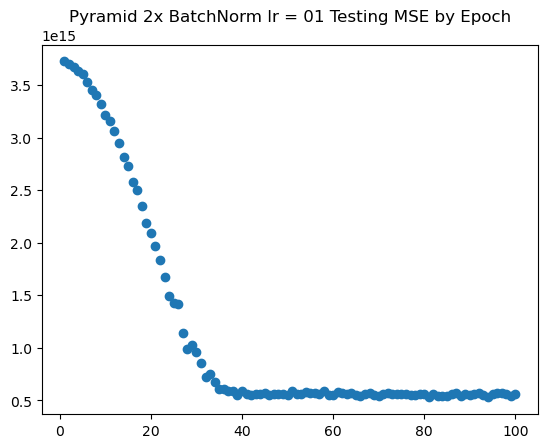

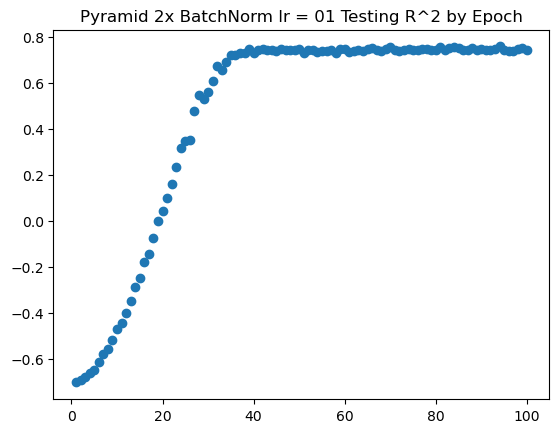

In [11]:
mse_p2_bn_2 = []
r_p2_bn_2 = []
pyramid2_bn_2 = Pyramid2xBN()
runNet(epoch_count, pyramid2_bn_2 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid2_bn_2.parameters(),lr=.01),criterion=nn.MSELoss(),variation="Pyramid 2x BatchNorm lr = 01",mse=mse_p2_bn_2,r2=r_p2_bn_2)

In [12]:
class Pyramid1x(nn.Module):
    def __init__(self):
        super(Pyramid1x, self).__init__()
        
        self.linear_LeakyReLU_stack = nn.Sequential(
            nn.Linear(input_size, input_size//2),
            nn.LeakyReLU(),
            nn.Linear(input_size//2, input_size//4),
            nn.LeakyReLU(),
            nn.Linear(input_size//4, output_size)
           
            
        )
    def forward(self, x):

        logits = self.linear_LeakyReLU_stack(x)
        return logits

Model: Pyramid1x(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=10, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=10, out_features=5, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=5, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epoch 30
----------
Epoch 31
----------
Epoch 32
----------
Epoch 33
----------
Epoch 34
----------
Epoch 35

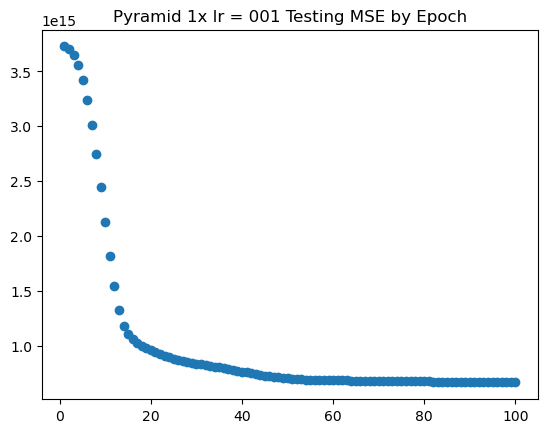

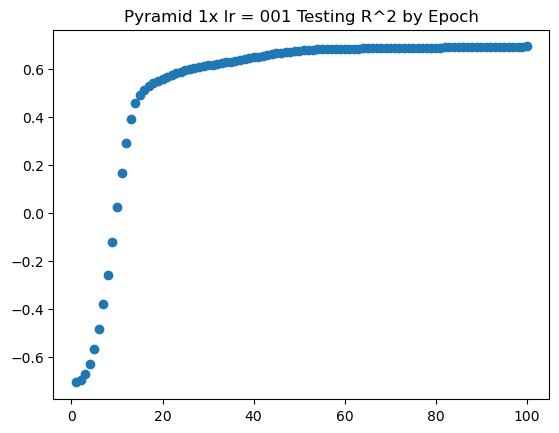

In [13]:
mse_p1 = []
r_p1 = []
pyramid1= Pyramid1x()
runNet(epoch_count, pyramid1 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid1.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 1x lr = 001",mse=mse_p1,r2=r_p1)

In [14]:
class PyramidInverted(nn.Module):
    def __init__(self):
        super(PyramidInverted, self).__init__()
        
        self.linear_LeakyReLU_stack = nn.Sequential(
            nn.Linear(input_size, 2*input_size),
            nn.LeakyReLU(),
            nn.Linear(2*input_size, 4*input_size),
            nn.LeakyReLU(),
            nn.Linear(4*input_size, 8*input_size),
            nn.LeakyReLU(),
            nn.Linear(8*input_size, output_size)
           
            
        )
    def forward(self, x):

        logits = self.linear_LeakyReLU_stack(x)
        return logits

Model: PyramidInverted(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=40, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=40, out_features=80, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=80, out_features=160, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=160, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
---------

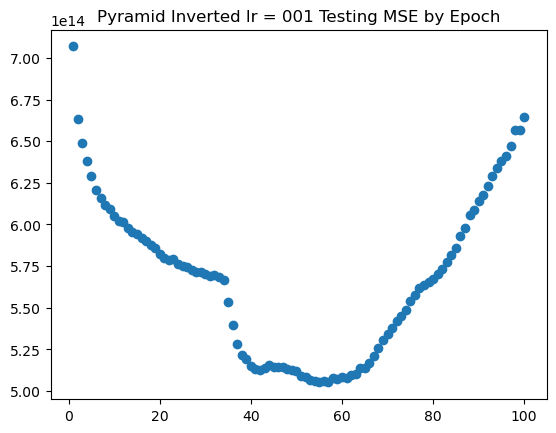

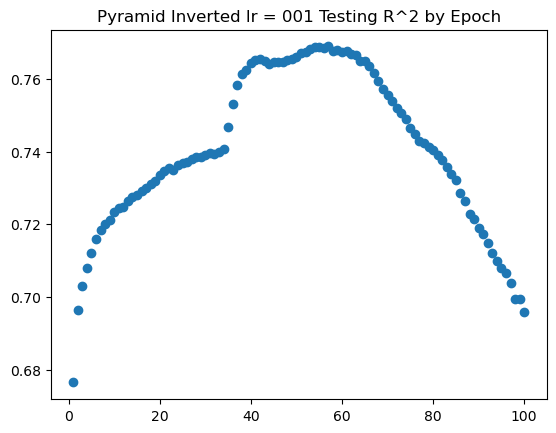

In [15]:
mse_invert = []
r_invert = []
pyramidI= PyramidInverted()
runNet(epoch_count, pyramidI ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramidI.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid Inverted lr = 001",mse=mse_invert,r2=r_invert)

Model: PyramidInverted(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=40, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=40, out_features=80, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=80, out_features=160, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=160, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
---------

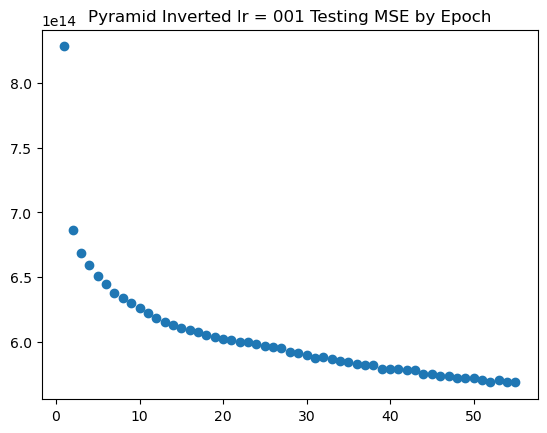

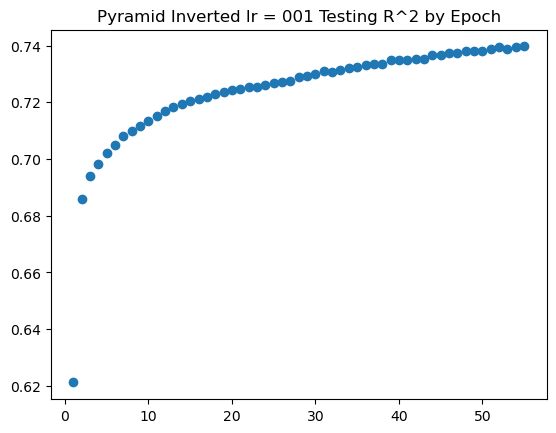

In [16]:
mse_invert1 = []
r_invert1 = []
pyramidI1= PyramidInverted()
runNet(55, pyramidI1 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramidI1.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid Inverted lr = 001",mse=mse_invert1,r2=r_invert1)

In [17]:
class Pyramid4xMod(nn.Module):
    def __init__(self):
        super(Pyramid4xMod, self).__init__()
        
        self.linear_LeakyReLU_stack = nn.Sequential(
            nn.Linear(input_size, 4*input_size),
            nn.LeakyReLU(),
            nn.Linear(4*input_size, 2*input_size),
            nn.LeakyReLU(),
            nn.Linear(2*input_size, input_size),
            nn.LeakyReLU(),
            nn.Linear(input_size, output_size),
           
            
        )
    def forward(self, x):

        logits = self.linear_LeakyReLU_stack(x)
        return logits


Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

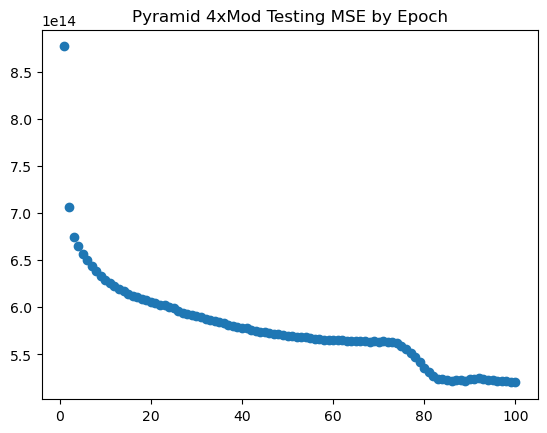

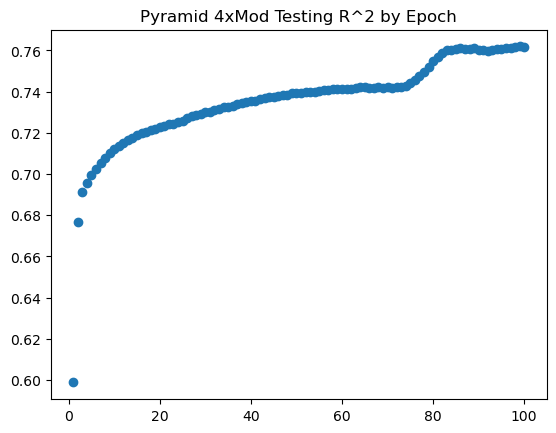

In [18]:
mse_p4m = []
r_p4m = []
pyramid4m = Pyramid4xMod()
runNet(epoch_count, pyramid4m ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid4m.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4xMod",mse=mse_p4m,r2=r_p4m)

Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

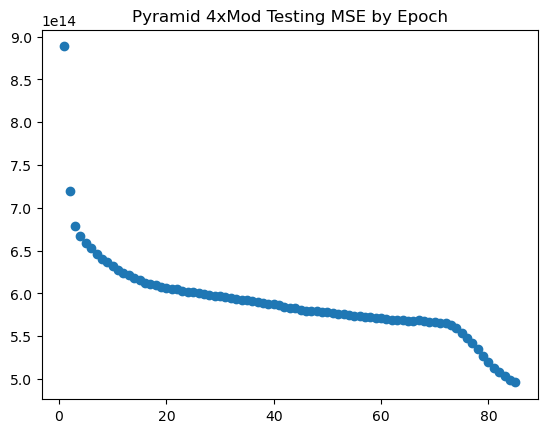

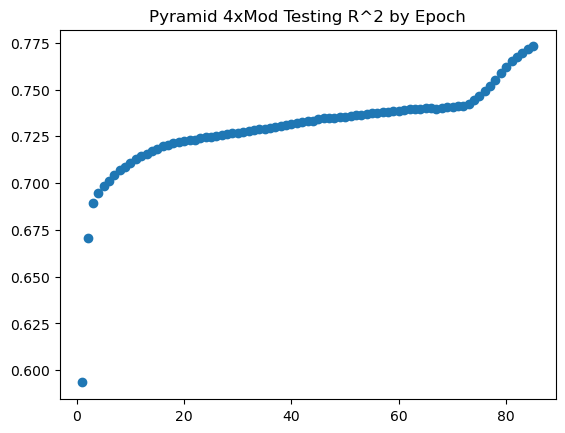

In [19]:
mse_p4m1 = []
r_p4m1 = []
pyramid4m1 = Pyramid4xMod()
runNet(85, pyramid4m1 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid4m1.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4xMod",mse=mse_p4m1,r2=r_p4m1)

In [20]:
# Same architecture as 4xMod but go up to 8x input size
class Pyramid8x(nn.Module):
    def __init__(self):
        super(Pyramid8x, self).__init__()
        
        self.linear_LeakyReLU_stack = nn.Sequential(
            nn.Linear(input_size, 8*input_size),
            nn.LeakyReLU(),
            nn.Linear(8*input_size, 4*input_size),
            nn.LeakyReLU(),
            nn.Linear(4*input_size, 2*input_size),
            nn.LeakyReLU(),
            nn.Linear(2*input_size, output_size),
           
            
        )
    def forward(self, x):

        logits = self.linear_LeakyReLU_stack(x)
        return logits


Model: Pyramid8x(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=160, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=160, out_features=80, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=80, out_features=40, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=40, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epoc

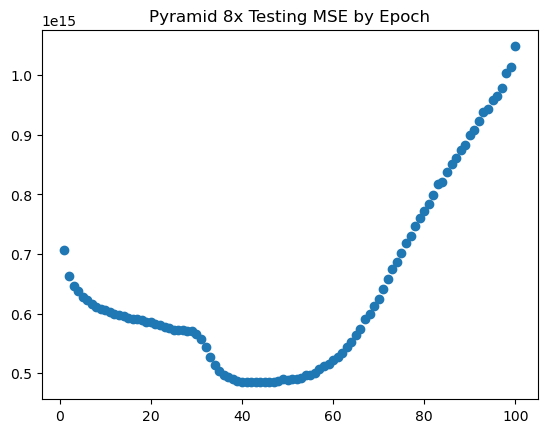

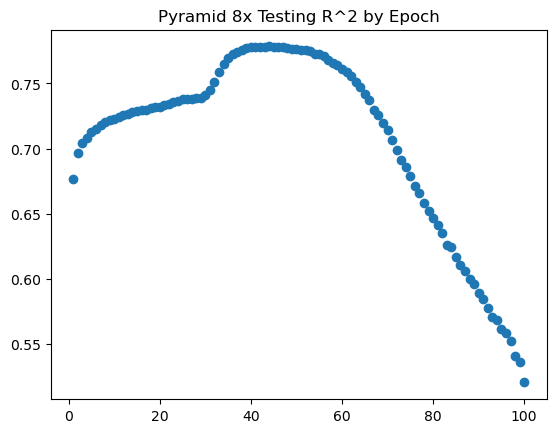

In [21]:
mse_p8 = []
r_p8 = []
pyramid8 = Pyramid8x()
runNet(epoch_count, pyramid8 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid8.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 8x",mse=mse_p8,r2=r_p8)

Model: Pyramid8x(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=160, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=160, out_features=80, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=80, out_features=40, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=40, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epoc

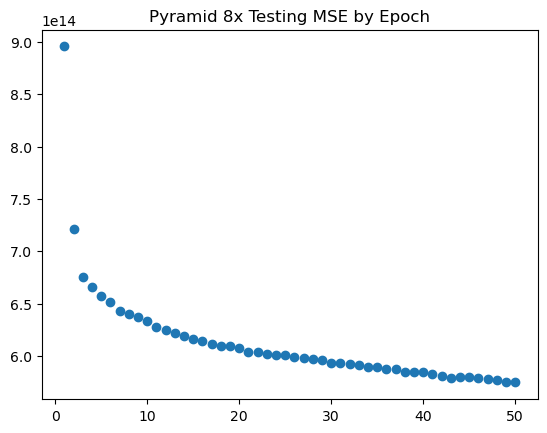

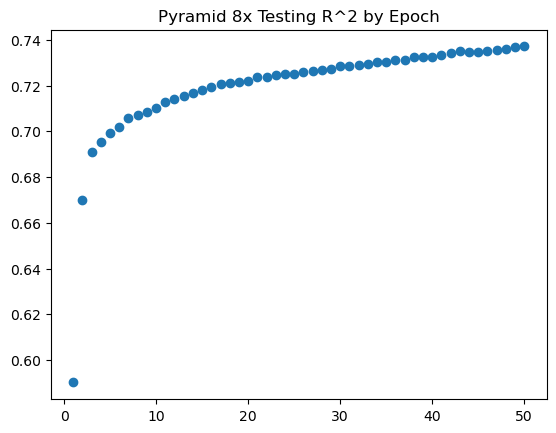

In [22]:
mse_p81 = []
r_p81 = []
pyramid81 = Pyramid8x()
runNet(50, pyramid81 ,train_loader, test_loader, optimizer=torch.optim.Adam(pyramid81.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 8x",mse=mse_p81,r2=r_p81)

Best of the NNs so Far: 4xMod. Now try different optimizers

Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

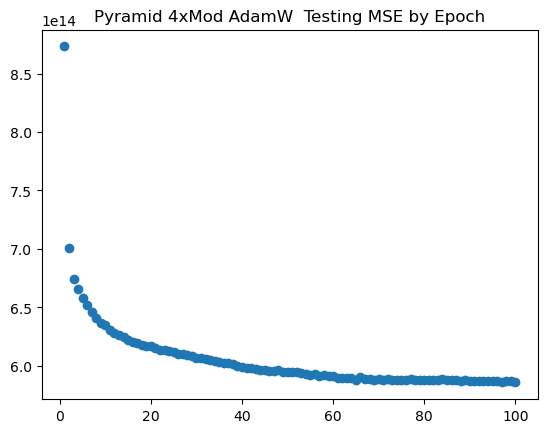

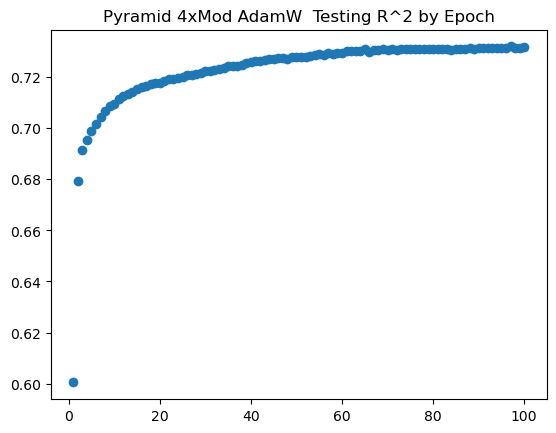

Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

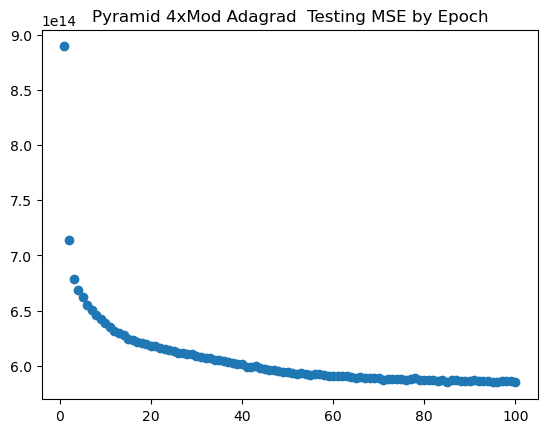

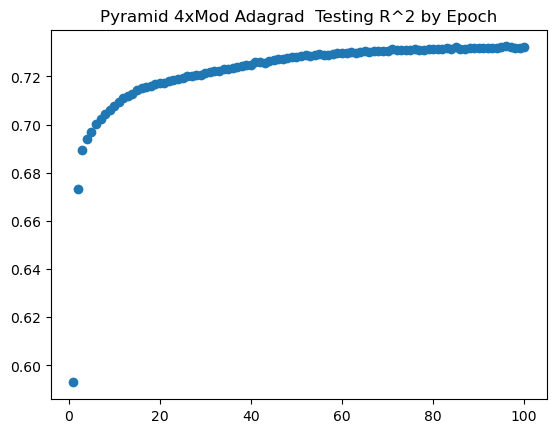

In [23]:
mse_p4mw = []
r_p4mw = []
pyramid4mw = Pyramid4xMod()
runNet(epoch_count, pyramid4mw ,train_loader, test_loader, optimizer=torch.optim.AdamW(pyramid4mw.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4xMod AdamW ",mse=mse_p4mw,r2=r_p4mw)

mse_p4m_ada = []
r_p4m_ada = []
pyramid4m_ada = Pyramid4xMod()
runNet(epoch_count, pyramid4m_ada ,train_loader, test_loader, optimizer=torch.optim.AdamW(pyramid4m_ada.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4xMod Adagrad ",mse=mse_p4m_ada,r2=r_p4m_ada)

Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

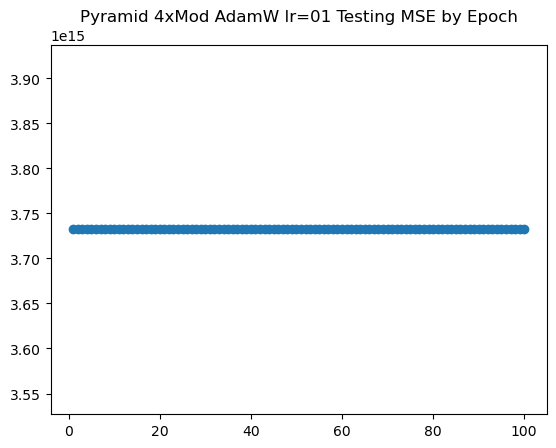

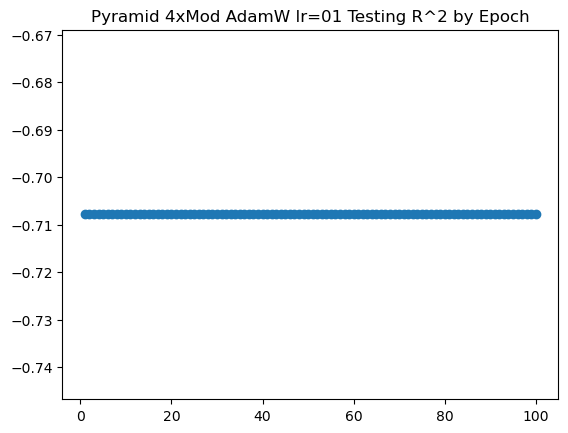

Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

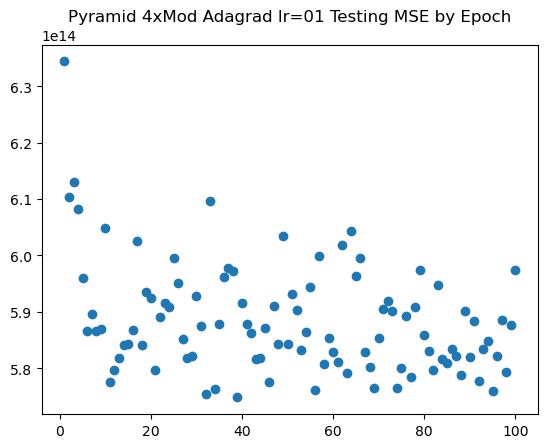

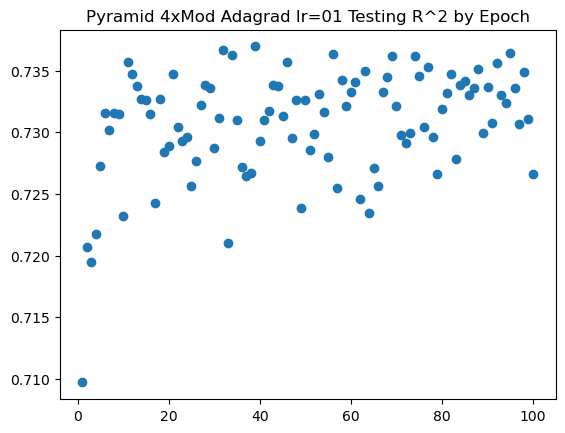

In [24]:
mse_p4mw_1 = []
r_p4mw_1= []
pyramid4mw_1 = Pyramid4xMod()
runNet(epoch_count, pyramid4mw_1 ,train_loader, test_loader, optimizer=torch.optim.AdamW(pyramid4mw.parameters(),lr=.01),criterion=nn.MSELoss(),variation="Pyramid 4xMod AdamW lr=01",mse=mse_p4mw_1,r2=r_p4mw_1)

mse_p4m_ada_1 = []
r_p4m_ada_1 = []
pyramid4m_ada_1 = Pyramid4xMod()
runNet(epoch_count, pyramid4m_ada_1 ,train_loader, test_loader, optimizer=torch.optim.AdamW(pyramid4m_ada_1.parameters(),lr=.01),criterion=nn.MSELoss(),variation="Pyramid 4xMod Adagrad lr=01",mse=mse_p4m_ada_1,r2=r_p4m_ada_1)

Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

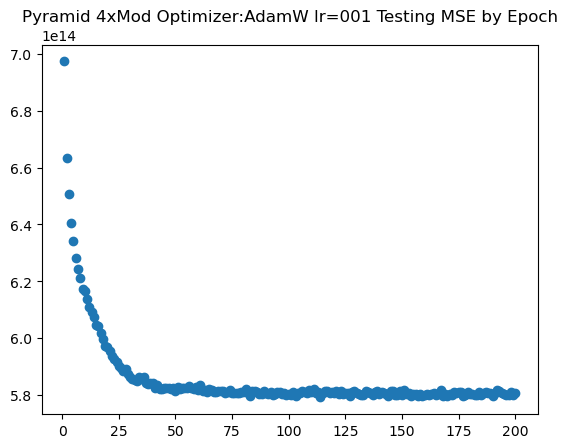

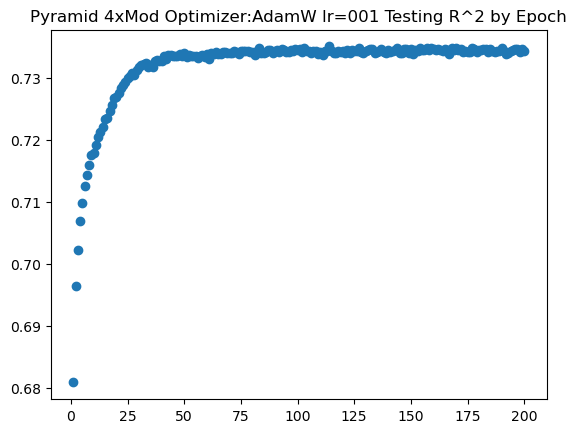

Model: Pyramid4xMod(
  (linear_LeakyReLU_stack): Sequential(
    (0): Linear(in_features=20, out_features=80, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=40, out_features=20, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epo

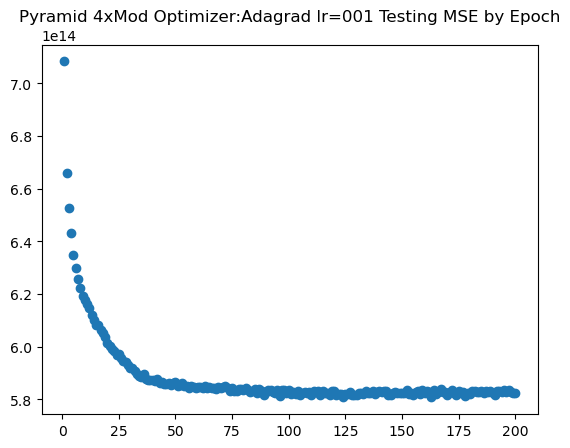

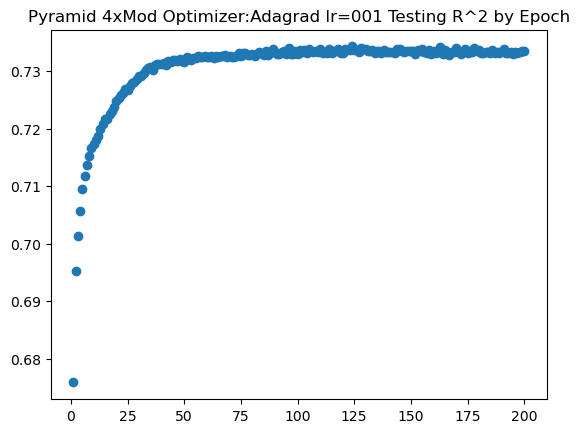

In [25]:
mse_p4mw_2= []
r_p4mw_2= []
pyramid4mw_2 = Pyramid4xMod()
runNet(200, pyramid4mw_2 ,train_loader, test_loader, optimizer=torch.optim.AdamW(pyramid4mw_2.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4xMod Optimizer:AdamW lr=001",mse=mse_p4mw_2,r2=r_p4mw_2)

mse_p4m_ada_2 = []
r_p4m_ada_2 = []
pyramid4m_ada_2 = Pyramid4xMod()
runNet(200, pyramid4m_ada_2 ,train_loader, test_loader, optimizer=torch.optim.AdamW(pyramid4m_ada_2.parameters(),lr=lr),criterion=nn.MSELoss(),variation="Pyramid 4xMod Optimizer:Adagrad lr=001",mse=mse_p4m_ada_2,r2=r_p4m_ada_2)